<a href="https://colab.research.google.com/github/mehatab-jan/python_Analytics/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns


In [3]:
df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors='coerce')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.dropna(how='any',inplace=True)

In [8]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
count_churn = df['Churn'].value_counts()//len(df)*100

In [ ]:
count_churn

,count
Churn,
No,0
Yes,0


In [ ]:
x = df.drop(['customerID','Churn'],axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [ ]:
y = df.Churn.values

In [ ]:
y

array(['No', 'No', 'Yes', ..., 'No', 'Yes', 'No'], dtype=object)

In [ ]:
x.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

**Feature Scaling** :converting categorical columns to numerical features

In [ ]:
x = pd.get_dummies(x,columns=['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod']
                   ,drop_first = True)

In [ ]:
x

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,False,True,True,True,False,True,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,False,False,False,True,False,False,True


Splitting data into training and testing data

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25)

In [ ]:
len(x_train)

5274

In [ ]:
len(x_test)

1758

**Feature scaling:**all the values should be in a specific scale

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)



In [ ]:
x_train_sc

array([[ 2.27024793, -0.75910677,  1.0287811 , ..., -0.52982902,
         1.41905401, -0.54974742],
       [-0.44048052,  1.36536654,  1.33958207, ...,  1.88740132,
        -0.70469481, -0.54974742],
       [ 2.27024793,  0.46655091,  0.34270448, ..., -0.52982902,
        -0.70469481, -0.54974742],
       ...,
       [-0.44048052, -0.88167253, -1.45597352, ...,  1.88740132,
        -0.70469481, -0.54974742],
       [-0.44048052,  0.91595872,  0.85684864, ...,  1.88740132,
        -0.70469481, -0.54974742],
       [-0.44048052,  1.36536654,  1.69667256, ..., -0.52982902,
        -0.70469481, -0.54974742]])

In [ ]:
x_test_sc

array([[-0.44048052, -0.35055421, -0.50207903, ...,  1.88740132,
        -0.70469481, -0.54974742],
       [-0.44048052, -1.24936984,  0.19556997, ..., -0.52982902,
         1.41905401, -0.54974742],
       [-0.44048052, -1.29022509, -1.47581188, ..., -0.52982902,
         1.41905401, -0.54974742],
       ...,
       [-0.44048052,  0.26227463, -0.45413633, ..., -0.52982902,
         1.41905401, -0.54974742],
       [-0.44048052, -0.2688437 , -0.96166771, ...,  1.88740132,
        -0.70469481, -0.54974742],
       [-0.44048052,  0.71168244,  0.17407841, ..., -0.52982902,
        -0.70469481, -0.54974742]])

KNN classifier

In [ ]:
#Call KNN classifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
#intialize the classifier
model = KNeighborsClassifier()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(x_train_sc,y_train)

x_train_pred  = knn.predict(x_train_sc)
x_test_pred = knn.predict(x_test_sc)

In [ ]:
x_test_pred

array(['No', 'Yes', 'No', ..., 'Yes', 'No', 'No'], dtype=object)

In [ ]:
y_test

array(['No', 'Yes', 'Yes', ..., 'Yes', 'No', 'No'], dtype=object)

In [ ]:
#confusion matrices to check how model is behaving/accuracy

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("ACCURACY:",accuracy_score(y_test,x_test_pred)*100)
print("Confusion:",confusion_matrix(y_test,x_test_pred))
print("report:",classification_report(y_test,x_test_pred))



ACCURACY: 76.90557451649602
Confusion: [[1155  130]
 [ 276  197]]
report:               precision    recall  f1-score   support

          No       0.81      0.90      0.85      1285
         Yes       0.60      0.42      0.49       473

    accuracy                           0.77      1758
   macro avg       0.70      0.66      0.67      1758
weighted avg       0.75      0.77      0.75      1758



In [ ]:
data=[[0,2,87,178,0,1,0,0,0,0,0,0,1,0,1,0,1,0,1,0,0,0,1,11,0,0,0,1,1,1]]

In [ ]:
data_sc = sc.transform(data)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
single = knn.predict(data_sc)

In [ ]:
print(single)

['No']


Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier


In [ ]:
model_dt = DecisionTreeClassifier()

In [ ]:
#passing the data
model_dt.fit(x_train_sc,y_train)

DecisionTreeClassifier()

In [ ]:
y_predict = model_dt.predict(x_test_sc)

In [ ]:
y_predict

array(['Yes', 'Yes', 'Yes', ..., 'No', 'No', 'No'], dtype=object)

In [ ]:
y_test

array(['No', 'Yes', 'Yes', ..., 'Yes', 'No', 'No'], dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score
print("accuracy:",accuracy_score(y_test,y_predict)*100)

accuracy: 72.46871444823664


In [ ]:
data=[[0,2,87,178,0,1,0,0,0,0,0,0,1,0,1,0,1,0,1,0,0,0,1,11,0,0,0,1,1,1]]

In [ ]:
data_dt = sc.transform(data)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
dec = model_dt.predict(data_dt)

In [ ]:
dec


array(['Yes'], dtype=object)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model_rf = RandomForestClassifier()

In [ ]:
model_rf.fit(x_train_sc,y_train)

RandomForestClassifier()

In [ ]:
y_predict = model_rf.predict(x_test_sc)

In [ ]:
y_predict

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [ ]:
y_test

array(['No', 'Yes', 'Yes', ..., 'Yes', 'No', 'No'], dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score
print("accuracy:",accuracy_score(y_test,y_predict)*100)

accuracy: 78.89647326507395


In [ ]:
data=[[0,2,87,178,0,1,0,0,0,0,0,0,1,0,1,0,1,0,1,0,0,0,1,11,0,0,0,1,1,1]]

In [ ]:
ran = model_rf.predict(data_dt)

In [ ]:
ran

array(['No'], dtype=object)

Clustering

In [10]:
x = df.iloc[:,[18,19]].values

In [16]:
from sklearn.cluster import KMeans

In [24]:
wcss=[]

In [25]:
import matplotlib.pyplot as plt

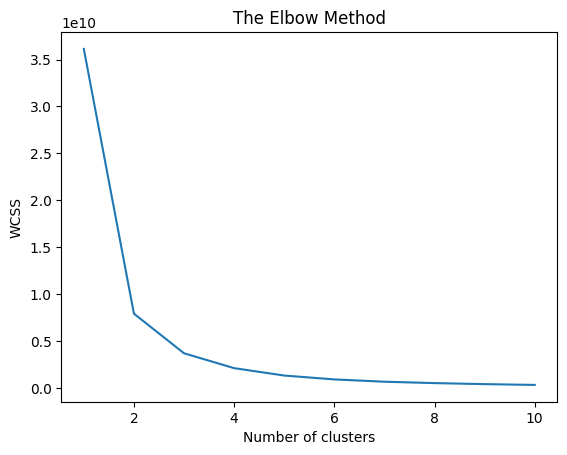

In [26]:
for i in range(1,11):
  Kmeans = KMeans(n_clusters=i,init='k-means++',max_iter=300,n_init=10,random_state=0)
  Kmeans.fit(x)
  wcss.append(Kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [27]:
# Number of clusters must be 5
#Apply Kmeans algorithm

kmeans = KMeans(n_clusters=5,init='k-means++',max_iter=300,n_init=10,random_state=None)
y_means = kmeans.fit_predict(x)

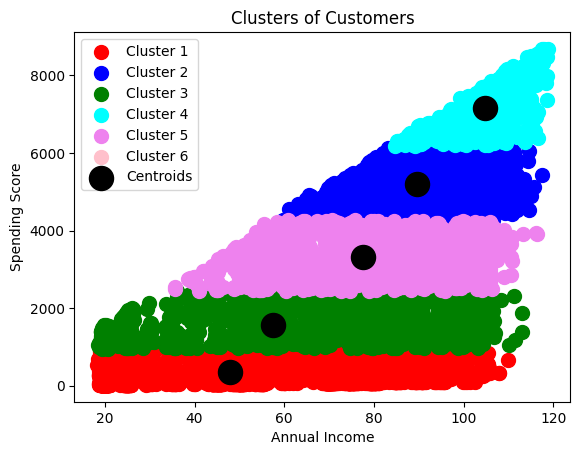

In [31]:
plt.scatter(x[y_means == 0, 0], x[y_means == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(x[y_means == 1, 0], x[y_means == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(x[y_means == 2, 0], x[y_means == 2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(x[y_means == 3, 0], x[y_means == 3, 1], s=100, c='cyan', label='Cluster 4')
plt.scatter(x[y_means == 4, 0], x[y_means == 4, 1], s=100, c='violet', label='Cluster 5')
plt.scatter(x[y_means == 5, 0], x[y_means == 5, 1], s=100, c='pink', label='Cluster 6')

plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300,
            c='black',
            label='Centroids')

plt.title('Clusters of Customers')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [32]:
df = pd.read_csv('/content/drive/MyDrive/AirPassengers.csv')

In [33]:
df.tail(5)

,Month,#Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [34]:
df.rename(columns={'#Passengers':'Passengers'},inplace=True)

In [35]:
df

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [37]:
# x convert it into datetime
df['Month'] = pd.to_datetime(df['Month'])

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [40]:
df

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [46]:
df = df.rename(columns={
    'Month': 'ds',
    'Passengers': 'y'
})

In [47]:
df

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [41]:
# fiting the prophet model

In [49]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
model = Prophet()
model.fit(df)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [50]:
future = model.make_future_dataframe(periods=36,freq='MS')
forecast = model.predict(future)


In [ ]:
#plot
plt.